# 🧠 Brain MRI Tumor Segmentation (U-Net)

This notebook builds a deep learning model to segment brain tumors from MRI images using a U-Net architecture.

### 📌 Project Overview
- Dataset: LGG MRI Segmentation Dataset
- Task: Binary segmentation (tumor vs background)
- Model: Custom U-Net (Encoder–Decoder)
- Framework: PyTorch

### ⚙️ Pipeline
1. Load & preprocess MRI images and masks  
2. Apply data augmentation (Albumentations)  
3. Build U-Net model  
4. Train using **combined loss (BCE + Dice loss)**  
5. Evaluate with Dice score & IoU  
6. Visualize predictions  

### 📊 Loss & Metrics
- **Loss Function:** BCE + Dice Loss  
- **Metrics:** Dice Score, IoU  

### 🎯 Goal
Accurately detect tumor regions to assist in medical image analysis.

---

Notebook is structured step-by-step for clarity and reproducibility 🚀

In [1]:
import os, cv2, numpy as np, torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
DATA_DIR ="/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

In [3]:
image_paths, mask_paths = [], []

for case in os.listdir(DATA_DIR):
    case_path =os.path.join(DATA_DIR ,case)

    if not os.path.isdir(case_path):
        continue

    files = os.listdir(case_path)

    for file in files:
        if "_mask" not in file:
            image_file =file
            mask_file = file.replace(".tif", "_mask.tif")

            image_path = os.path.join(case_path, image_file)
            mask_path = os.path.join(case_path, mask_file)

            if os.path.exists(mask_path):
                image_paths.append(image_path)
                mask_paths.append(mask_path)

In [4]:
print(len(image_paths), len(mask_paths))
print(image_paths[0])
print(mask_paths[0])

3929 3929
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45_mask.tif


In [5]:
from sklearn.model_selection import train_test_split

train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
    image_paths, mask_paths, test_size=0.3, random_state=42
)

val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    temp_imgs, temp_masks, test_size=0.5, random_state=42
)

## 🧪 Data-Centric Approach

Instead of increasing model complexity, this notebook focuses on improving data quality and diversity.

### ⚙️ Augmentation Strategy
The training pipeline applies:
- Spatial transformations (flip, rotation, shift)
- Geometric distortions (elastic, grid, optical)
- Visual variations (brightness, contrast, noise)
- Standard normalization

### Augmentation

In [10]:
train_transform = A.Compose([
    # 1. Combined Cropping and Resizing
    A.Resize(256, 256),

    # 2. Spatial Transforms
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2), # Keep only if orientation doesn't matter
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.0, rotate_limit=15, p=0.5),
    
    # 3. Morphological Transforms
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.5),
        A.GridDistortion(p=0.5),
        A.OpticalDistortion(distort_limit=1, p=1),
    ], p=0.2),

    # 4. Visual/Noise Transforms
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.15),
    
    # 5. Normalization (Crucial for convergence!)
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [11]:
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [12]:
class BrainDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        mask = cv2.imread(self.mask_paths[idx], 0)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]        
            mask = augmented["mask"]
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
            mask = torch.tensor(mask, dtype=torch.float32)    

        mask = mask.float().unsqueeze(0) / 255.0  # (1, H, W), values 0-1
        return img, mask

In [13]:
train_dataset = BrainDataset(train_imgs, train_masks, transform=train_transform)
val_dataset   = BrainDataset(val_imgs,   val_masks,   transform=val_transform)
test_dataset  = BrainDataset(test_imgs,  test_masks,  transform=val_transform)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

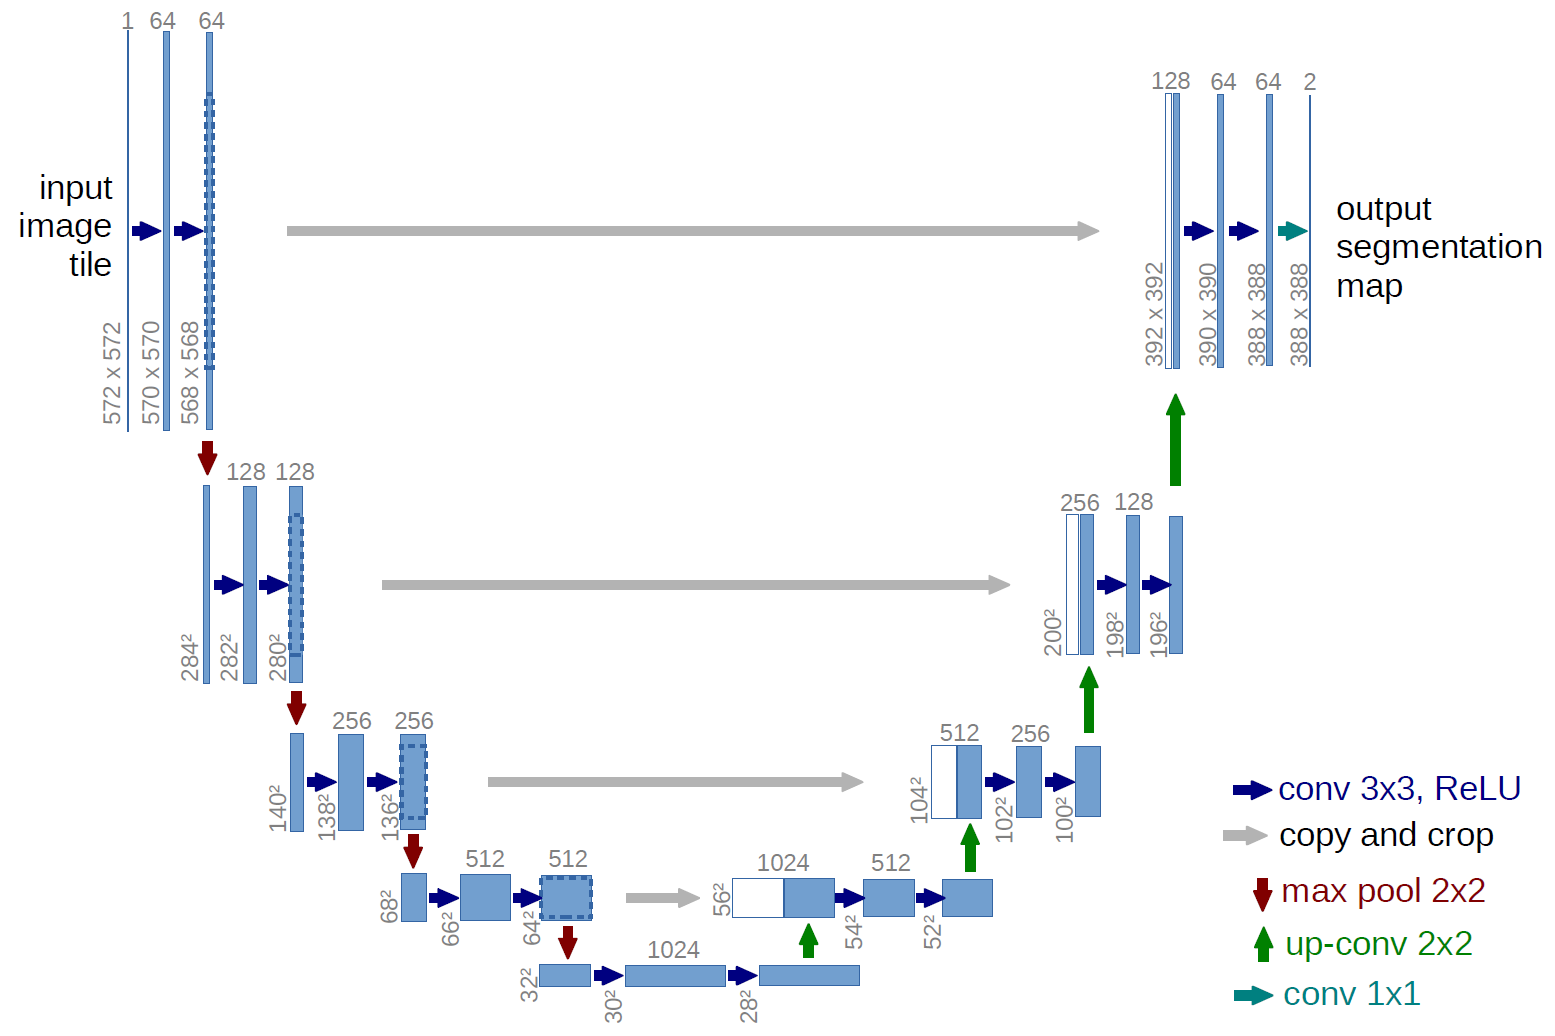

## 🏗️ Model Design Choice

The original U-Net architecture is typically built with **5 encoder–decoder blocks**.  

In this notebook, a **lighter version with 4 blocks** is used instead.

### 🔍 Why a Smaller Model?
- Reduces computational cost  
- Faster training and experimentation  
- Lower risk of overfitting on limited medical data  

### 🧪 Focus on Data Over Model Size
Rather than increasing model depth, the focus is placed on:
- Strong data augmentation  
- Better generalization  
- High-quality training samples  

### 🎯 Key Insight
Improving data quality and diversity can be more effective than increasing model complexity, especially in medical imaging tasks.

### Build a proper Conv Block

In [15]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

### Encoder

In [16]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = ConvBlock(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.conv4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)

    def forward(self, x):
        x1 = self.conv1(x)   # (64, 256, 256)
        x2 = self.conv2(self.pool1(x1))  # (128, 128, 128)
        x3 = self.conv3(self.pool2(x2))  # (256, 64, 64)
        x4 = self.conv4(self.pool3(x3))  # (512, 32, 32)

        out = self.pool4(x4)

        return x1, x2, x3, x4, out

### Bottleneck

In [17]:
class Bottleneck(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = ConvBlock(512, 512) # was 512→1024, now 512→512
        self.dropout = nn.Dropout2d(p=0.3) # not normal Dropout

    def forward(self, x):
        x = self.conv(x)
        x = self.dropout(x)
        return x

### Decoder

In [18]:
import torch.nn.functional as F

class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        # FIX: match size
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)

        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

In [19]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.up1 = UpBlock(512, 512, 256)   # was UpBlock(1024, 512, 512)
        self.up2 = UpBlock(256, 256, 128)   # was UpBlock(512,  256, 256)
        self.up3 = UpBlock(128, 128, 64)    # was UpBlock(256,  128, 128)
        self.up4 = UpBlock(64,   64,  32)   # was UpBlock(128,   64,  64)

    def forward(self, x, x1, x2, x3, x4):
        x = self.up1(x, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return x

### Assemble Full U-Net

In [20]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.bottleneck = Bottleneck()
        self.decoder = Decoder()

        self.final = nn.Conv2d(32, 1, kernel_size=1) # was Conv2d(64, 1, ...)

    def forward(self, x):
        
        x1, x2, x3, x4, out = self.encoder(x)
        
        out = self.bottleneck(out)
        
        out = self.decoder(out, x1, x2, x3, x4) 

        return self.final(out)

## 📉 Loss Function (BCE + Dice)

- **BCE** → pixel-level accuracy  
- **Dice** → overlap quality  

➡️ Combined for stable training + better segmentation.

### Loss Function (BCE + Dice)

In [21]:
def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)  # convert logits → probs

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2. * intersection + smooth) / (union + smooth)

    return 1 - dice

In [22]:
bce = nn.BCEWithLogitsLoss()

def combined_loss(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

### Metrics (IoU + Dice)

In [23]:
def dice_coef(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * intersection) / (union + 1e-6)

In [24]:
def iou_coef(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return intersection / (union + 1e-6)

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [26]:
model = UNet().to(device)

## ⚙️ Optimization

- **AdamW** → adaptive optimizer with better regularization  
- **ReduceLROnPlateau** → reduces learning rate when validation loss stops improving  

➡️ Helps achieve stable training and better convergence.

In [27]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5 ,min_lr=1e-6
)

In [28]:
history = {
    "train_loss": [], "val_loss": [],
    "train_dice": [], "val_dice": [],
    "train_iou": [], "val_iou": []
}

In [29]:
best_val_loss = float("inf")
patience = 10
counter = 0

In [30]:
epochs = 100

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    
    train_loss = 0
    train_dice = 0
    train_iou = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        loss = combined_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_coef(preds, masks).item()
        train_iou += iou_coef(preds, masks).item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    train_iou /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()

    val_loss = 0
    val_dice = 0
    val_iou = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            loss = combined_loss(preds, masks)

            val_loss += loss.item()
            val_dice += dice_coef(preds, masks).item()
            val_iou += iou_coef(preds, masks).item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    scheduler.step(val_loss)

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

    # ===== SAVE HISTORY =====
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    # ===== PRINT =====
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} |Train Dice: {train_dice:.4f} |Train IoU: {train_iou:.4f}")
    print(f"Val   Loss: {val_loss:.4f} |Val Dice: {val_dice:.4f} |Val IoU: {val_iou:.4f}")
    print("-" * 50)

print(f"Best Val Loss: {best_val_loss:.4f}")

Epoch 1/100
Train Loss: 1.3525 |Train Dice: 0.3816 |Train IoU: 0.2557
Val   Loss: 1.3146 |Val Dice: 0.2695 |Val IoU: 0.1618
--------------------------------------------------
Epoch 2/100
Train Loss: 1.1591 |Train Dice: 0.5386 |Train IoU: 0.3907
Val   Loss: 1.0765 |Val Dice: 0.5627 |Val IoU: 0.4100
--------------------------------------------------
Epoch 3/100
Train Loss: 1.0312 |Train Dice: 0.5696 |Train IoU: 0.4196
Val   Loss: 0.9628 |Val Dice: 0.5991 |Val IoU: 0.4398
--------------------------------------------------
Epoch 4/100
Train Loss: 0.9048 |Train Dice: 0.5855 |Train IoU: 0.4358
Val   Loss: 0.8158 |Val Dice: 0.6903 |Val IoU: 0.5432
--------------------------------------------------
Epoch 5/100
Train Loss: 0.7588 |Train Dice: 0.6147 |Train IoU: 0.4647
Val   Loss: 0.6944 |Val Dice: 0.5830 |Val IoU: 0.4278
--------------------------------------------------
Epoch 6/100
Train Loss: 0.5959 |Train Dice: 0.6515 |Train IoU: 0.5031
Val   Loss: 0.6329 |Val Dice: 0.6017 |Val IoU: 0.4604
-

## 📊 Training Results

- **Best Validation Loss:** 0.1188  
- **Dice Score:** ~0.89  
- **IoU:** ~0.81  

### 🔍 Observations
- Stable training with close train/validation performance  
- No significant overfitting  
- Early stopping prevented unnecessary training  

➡️ The model achieves strong segmentation performance with good generalization.

In [33]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

UNet(
  (encoder): Encoder(
    (conv1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_ru

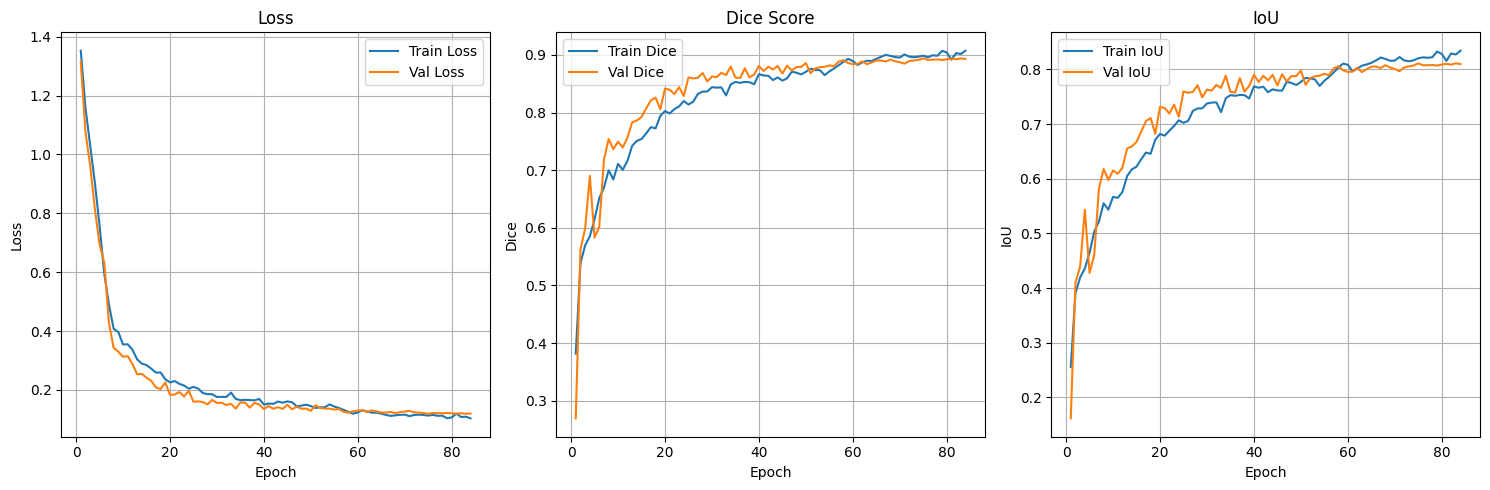

In [41]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(15, 5))

# ===== Loss =====
plt.subplot(1, 3, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# ===== Dice =====
plt.subplot(1, 3, 2)
plt.plot(epochs, history["train_dice"], label="Train Dice")
plt.plot(epochs, history["val_dice"], label="Val Dice")
plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid()

# ===== IoU =====
plt.subplot(1, 3, 3)
plt.plot(epochs, history["train_iou"], label="Train IoU")
plt.plot(epochs, history["val_iou"], label="Val IoU")
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [49]:
def evaluate_model(loader, name="Test"):
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)
            loss = combined_loss(preds, masks)

            # USE SAME FUNCTIONS
            dice = dice_coef(preds, masks)
            iou = iou_coef(preds, masks)

            total_loss += loss.item()
            total_dice += dice.item()
            total_iou += iou.item()

    total_loss /= len(loader)
    total_dice /= len(loader)
    total_iou /= len(loader)

    print(f"{name} Loss:  {total_loss:.4f}")
    print(f"{name} IoU:   {total_iou:.4f}")
    print(f"{name} Dice:  {total_dice:.4f}")
    print("-" * 20)

In [50]:
evaluate_model(train_loader, "Train")
evaluate_model(val_loader, "Valid")
evaluate_model(test_loader, "Test")

Train Loss:  0.1111
Train IoU:   0.8228
Train Dice:  0.9000
--------------------
Valid Loss:  0.1188
Valid IoU:   0.8110
Valid Dice:  0.8941
--------------------
Test Loss:  0.1213
Test IoU:   0.8090
Test Dice:  0.8920
--------------------


## 📊 Final Evaluation

| Split  | Loss  | Dice  | IoU   |
|--------|------|-------|-------|
| Train  | 0.111 | 0.900 | 0.823 |
| Valid  | 0.119 | 0.894 | 0.811 |
| Test   | 0.121 | 0.892 | 0.809 |

### 🔍 Summary
- Consistent performance across all splits  
- Very small gap → good generalization  
- No strong overfitting  

➡️ The model is stable and performs well on unseen data.

## 👁️ Visualization

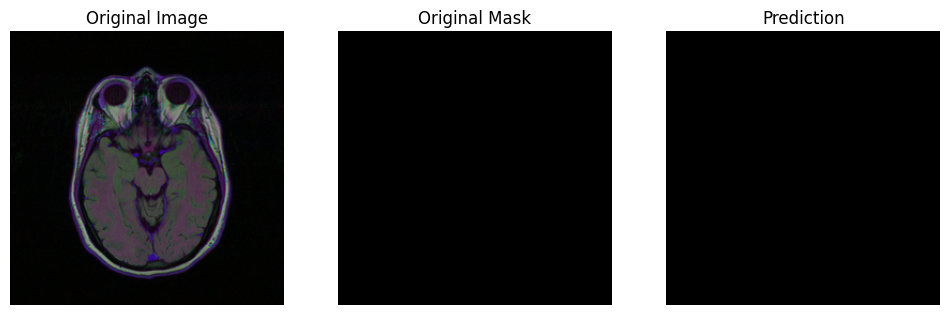

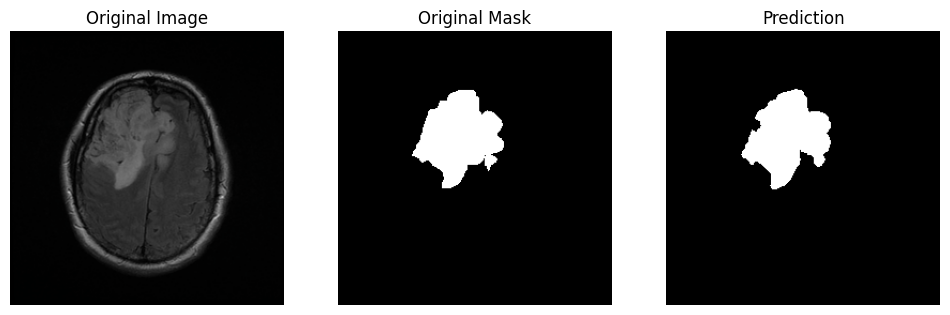

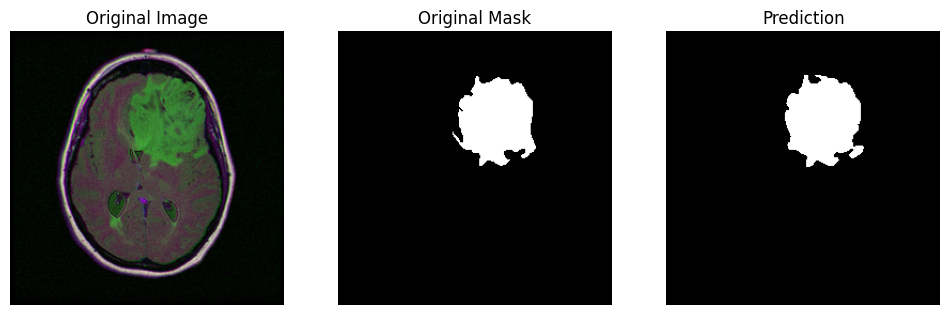

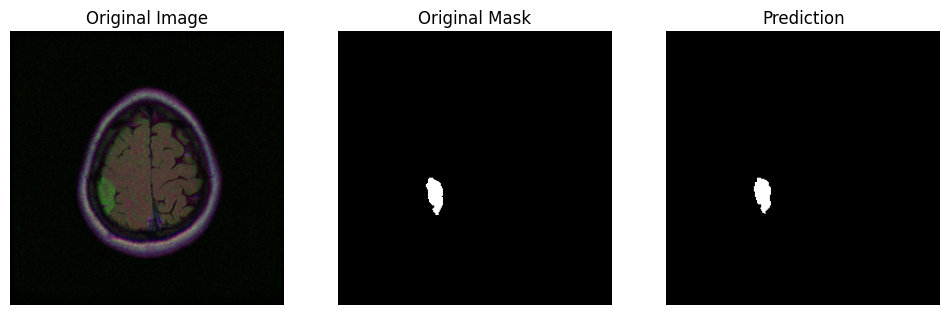

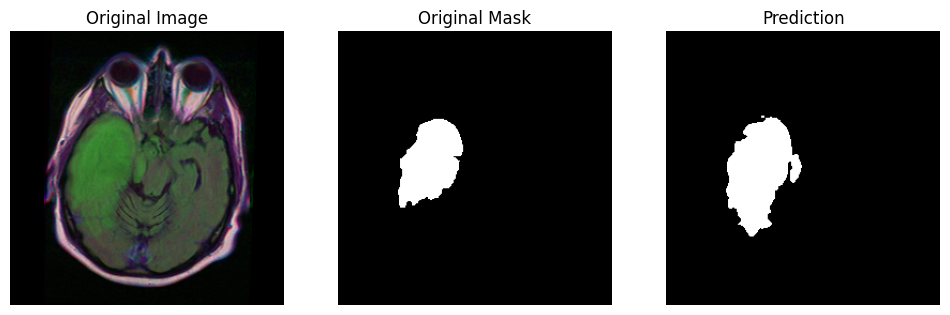

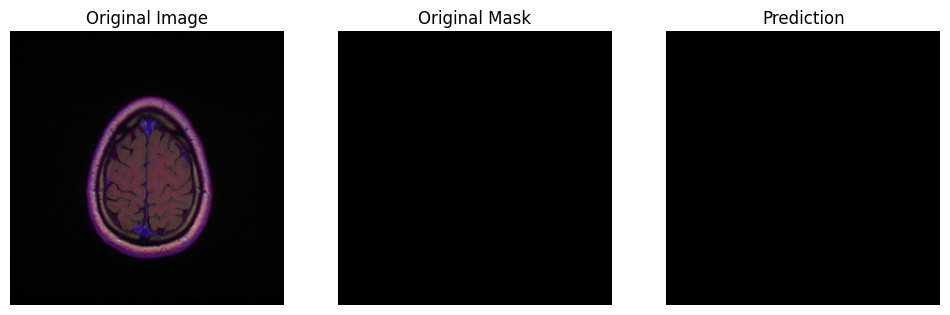

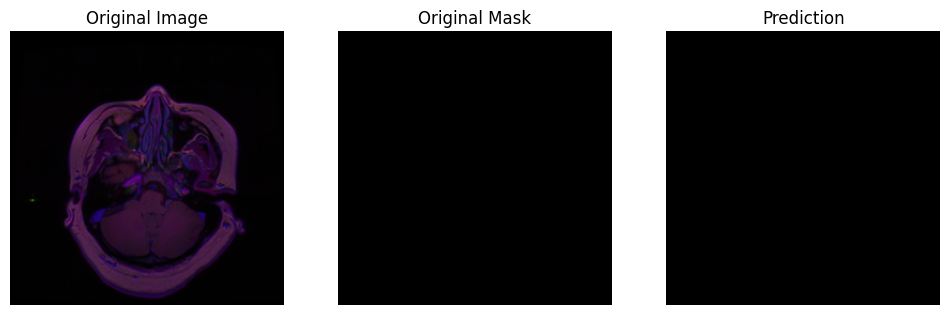

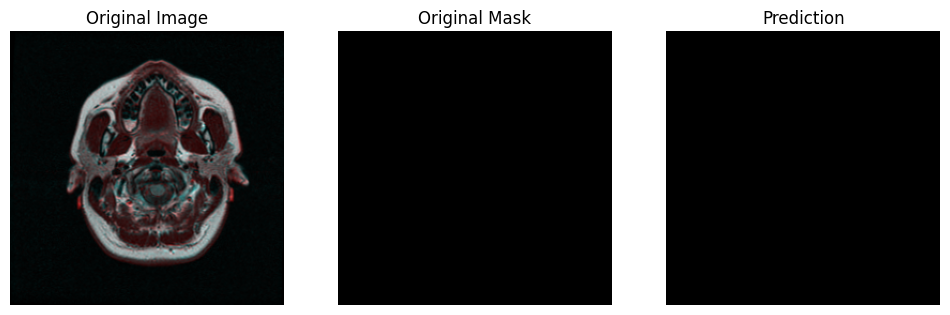

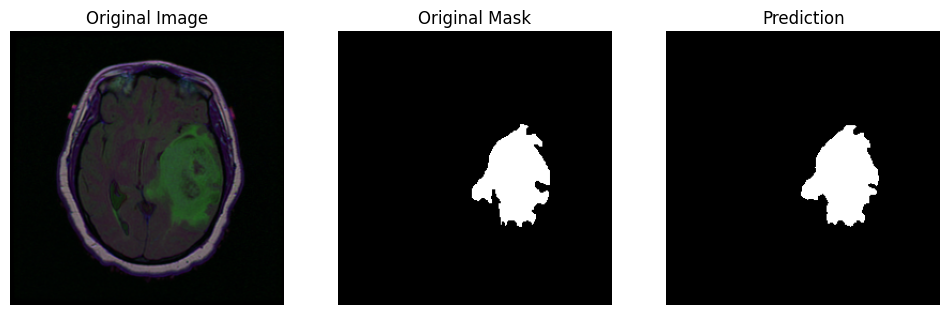

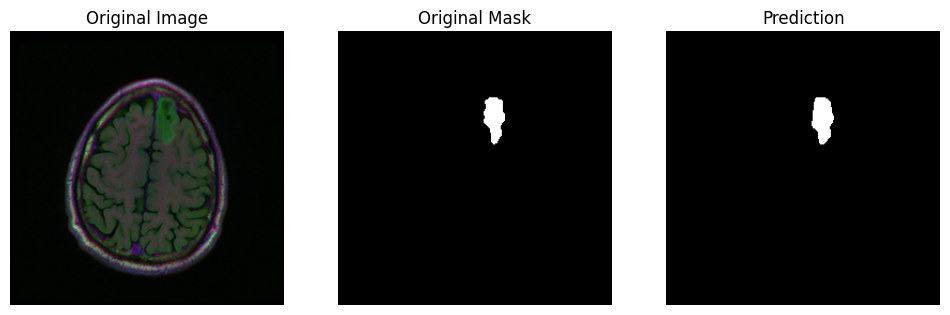

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# correct denormalization for RGB
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img


def visualize_predictions(loader, num_images=10):
    model.load_state_dict(torch.load("best_model.pth"))
    model.eval()

    count = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)
            probs = torch.sigmoid(preds)
            preds = (probs > 0.35).float()

            for i in range(imgs.size(0)):
                if count >= num_images:
                    return

                # ✅ FIXED IMAGE
                img = imgs[i].cpu().permute(1, 2, 0).numpy()
                img = denormalize(img)

                # mask
                mask = masks[i].cpu().squeeze().numpy()

                # prediction
                pred = preds[i].cpu().squeeze().numpy()

                plt.figure(figsize=(12, 4))

                plt.subplot(1, 3, 1)
                plt.imshow(img)
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(mask, cmap="gray")
                plt.title("Original Mask")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(pred, cmap="gray")
                plt.title("Prediction")
                plt.axis("off")

                plt.show()

                count += 1


# run
visualize_predictions(test_loader, num_images=10)